# 03 — Engagement & Attendance Patterns

Análise de padrões comportamentais baseada em dados de ponto (check-in/check-out).

Este notebook explora uma dimensão que vai além das pesquisas de satisfação: **o que o comportamento real dos colaboradores nos diz?** Utilizando 261 dias de registros de entrada e saída, identificamos padrões de jornada, absenteísmo sazonal, e sinais comportamentais que antecedem a saída.

**Diferencial:** A maioria das análises de RH depende exclusivamente de dados declarados (pesquisas, avaliações). Aqui cruzamos dados *comportamentais observados* com outcomes de attrition.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

COLORS = {
    'primary': '#6366F1', 'secondary': '#8B5CF6', 'accent': '#EC4899',
    'success': '#10B981', 'warning': '#F59E0B', 'danger': '#EF4444',
    'info': '#06B6D4', 'text': '#E2E8F0', 'muted': '#94A3B8',
    'bg': '#0F172A', 'card': '#1E293B', 'grid': '#334155'
}
PALETTE_CAT = ['#6366F1', '#EC4899', '#10B981', '#F59E0B', '#06B6D4', '#8B5CF6', '#EF4444', '#14B8A6', '#F97316']
ATTRITION_COLORS = {'Yes': COLORS['danger'], 'No': COLORS['success']}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['card'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'], 'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'], 'grid.color': COLORS['grid'],
    'grid.alpha': 0.3, 'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
})

def format_ax(ax, title='', xlabel='', ylabel='', grid_axis='y'):
    ax.set_title(title, pad=15, loc='left')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if grid_axis: ax.grid(axis=grid_axis, alpha=0.2, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load master dataset and daily events
df = pd.read_csv('../data/processed/master_dataset.csv')
df_events = pd.read_csv('../data/processed/daily_events.csv', parse_dates=['Date', 'InTime', 'OutTime'])

print(f'Master dataset: {df.shape[0]:,} employees × {df.shape[1]} features')
print(f'Daily events: {df_events.shape[0]:,} records')
print(f'Date range: {df_events["Date"].min().date()} to {df_events["Date"].max().date()}')

Master dataset: 4,410 employees × 51 features
Daily events: 1,098,090 records
Date range: 2015-01-02 to 2015-12-31


---
## 2. Work Hours Profile

Understanding the normative work pattern across the organization.

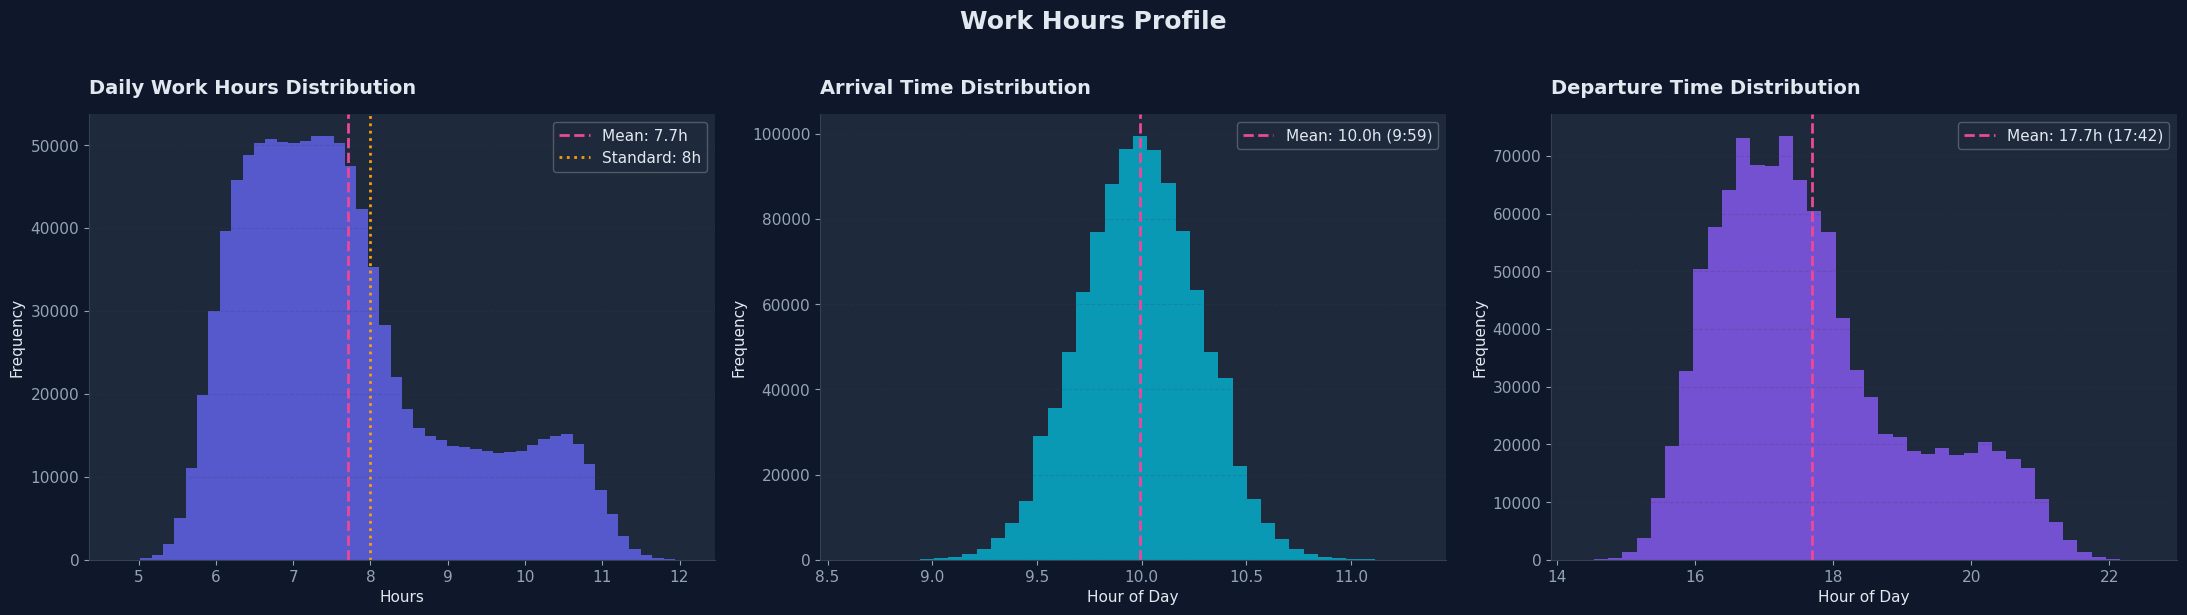

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Work Hours Profile', fontsize=18, fontweight='bold', y=1.02)

# ── Work hours distribution ──
ax = axes[0]
work_hours = df_events['WorkHours'].dropna()
ax.hist(work_hours, bins=50, color=COLORS['primary'], edgecolor='none', alpha=0.8)
ax.axvline(work_hours.mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Mean: {work_hours.mean():.1f}h')
ax.axvline(8, color=COLORS['warning'], linestyle=':', linewidth=2, label='Standard: 8h')
format_ax(ax, 'Daily Work Hours Distribution', 'Hours', 'Frequency')
ax.legend(framealpha=0.3)

# ── Arrival time distribution ──
ax = axes[1]
arrival = df_events['ArrivalHour'].dropna()
ax.hist(arrival, bins=40, color=COLORS['info'], edgecolor='none', alpha=0.8)
ax.axvline(arrival.mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Mean: {arrival.mean():.1f}h ({int(arrival.mean())}:{int((arrival.mean()%1)*60):02d})')
format_ax(ax, 'Arrival Time Distribution', 'Hour of Day', 'Frequency')
ax.legend(framealpha=0.3)

# ── Departure time distribution ──
ax = axes[2]
departure = df_events['DepartureHour'].dropna()
ax.hist(departure, bins=40, color=COLORS['secondary'], edgecolor='none', alpha=0.8)
ax.axvline(departure.mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Mean: {departure.mean():.1f}h ({int(departure.mean())}:{int((departure.mean()%1)*60):02d})')
format_ax(ax, 'Departure Time Distribution', 'Hour of Day', 'Frequency')
ax.legend(framealpha=0.3)

plt.tight_layout()
plt.savefig('../reports/work_hours_profile.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

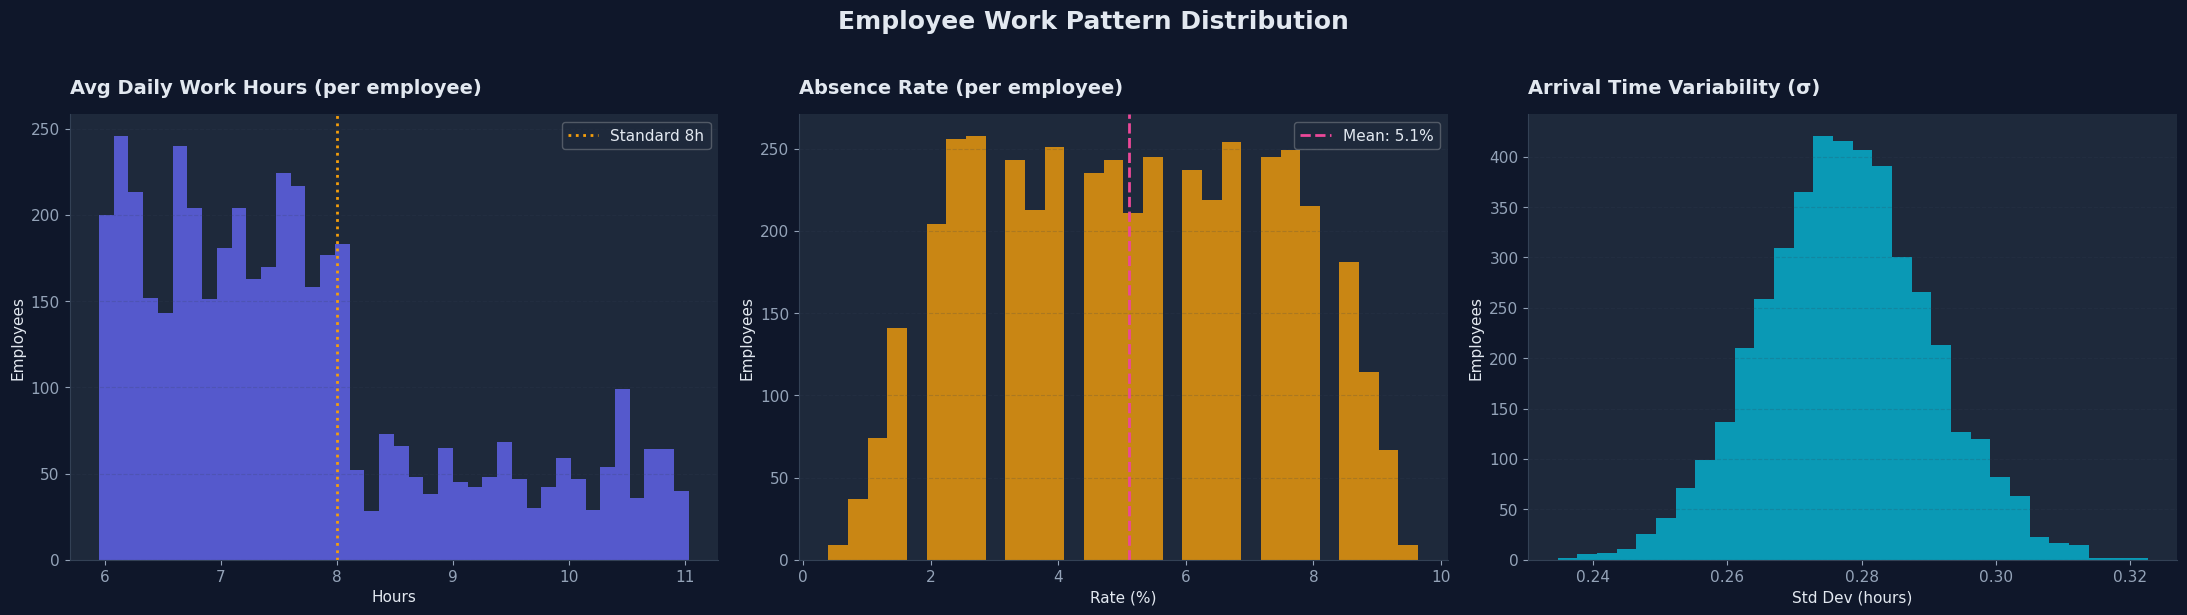

In [4]:
# Employee-level work pattern clusters
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Employee Work Pattern Distribution', fontsize=18, fontweight='bold', y=1.02)

# ── Avg daily hours per employee ──
ax = axes[0]
ax.hist(df['AvgDailyWorkHours'], bins=40, color=COLORS['primary'], edgecolor='none', alpha=0.8)
ax.axvline(8, color=COLORS['warning'], linestyle=':', linewidth=2, label='Standard 8h')
format_ax(ax, 'Avg Daily Work Hours (per employee)', 'Hours', 'Employees')
ax.legend(framealpha=0.3)

# ── Absence rate per employee ──
ax = axes[1]
ax.hist(df['AbsenceRate'], bins=30, color=COLORS['warning'], edgecolor='none', alpha=0.8)
ax.axvline(df['AbsenceRate'].mean(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Mean: {df["AbsenceRate"].mean():.1f}%')
format_ax(ax, 'Absence Rate (per employee)', 'Rate (%)', 'Employees')
ax.legend(framealpha=0.3)

# ── Arrival variability ──
ax = axes[2]
ax.hist(df['StdArrivalHour'].dropna(), bins=30, color=COLORS['info'], edgecolor='none', alpha=0.8)
format_ax(ax, 'Arrival Time Variability (σ)', 'Std Dev (hours)', 'Employees')

plt.tight_layout()
plt.savefig('../reports/work_patterns_employee.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 3. Absenteeism Analysis

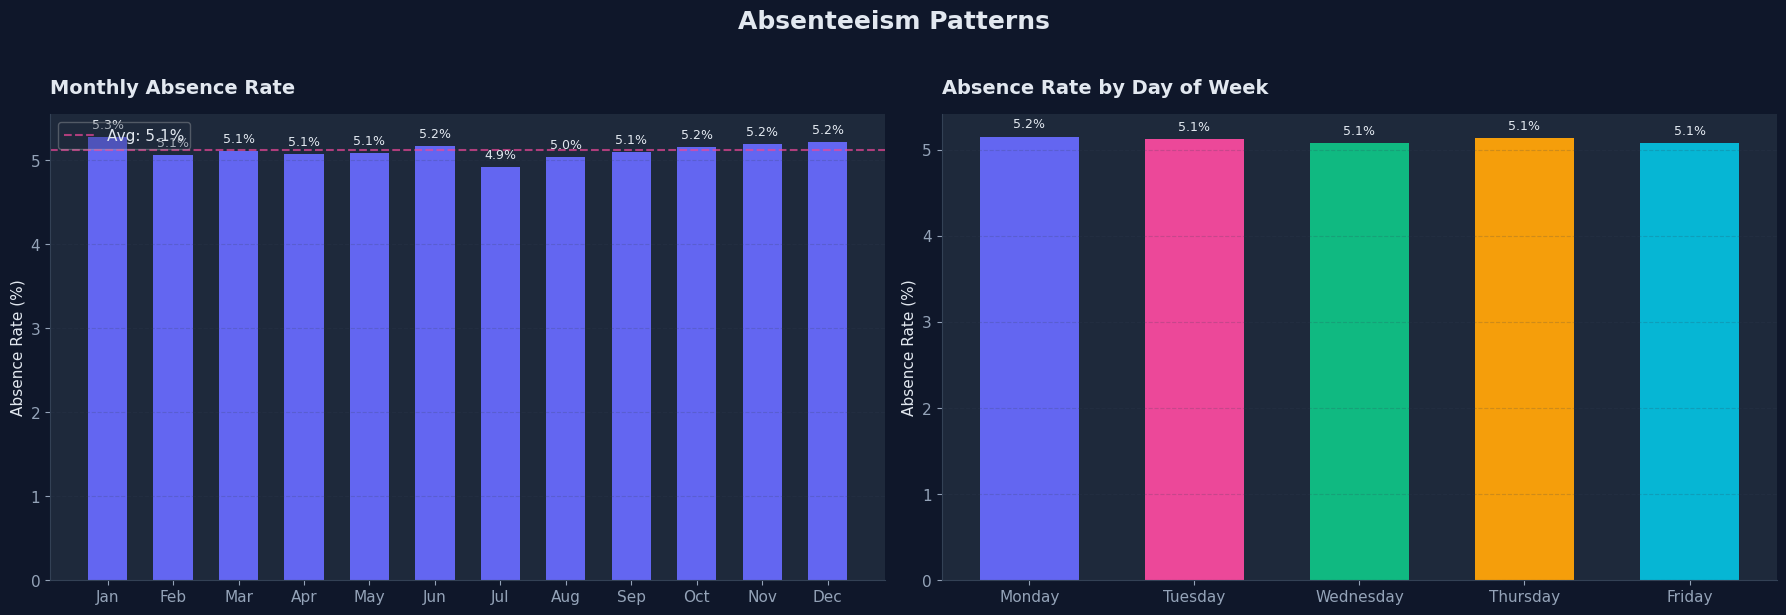

In [5]:
# Monthly absence pattern — seasonality
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_absence = df_events.groupby('Month')['Absent'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Absenteeism Patterns', fontsize=18, fontweight='bold', y=1.02)

# ── Monthly trend ──
ax = axes[0]
x_labels = [month_names[m] for m in monthly_absence.index]
bars = ax.bar(x_labels, monthly_absence.values, color=COLORS['primary'], edgecolor='none', width=0.6)
for bar, val in zip(bars, monthly_absence.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}%', 
            ha='center', fontsize=9, color=COLORS['text'])
ax.axhline(monthly_absence.mean(), color=COLORS['accent'], linestyle='--', alpha=0.7,
           label=f'Avg: {monthly_absence.mean():.1f}%')
format_ax(ax, 'Monthly Absence Rate', '', 'Absence Rate (%)')
ax.legend(framealpha=0.3)

# ── Day of week pattern ──
ax = axes[1]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
daily_absence = df_events.groupby('DayOfWeek')['Absent'].mean().reindex(day_order) * 100
bars = ax.bar(daily_absence.index, daily_absence.values, color=PALETTE_CAT[:5], edgecolor='none', width=0.6)
for bar, val in zip(bars, daily_absence.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.1f}%',
            ha='center', fontsize=9, color=COLORS['text'])
format_ax(ax, 'Absence Rate by Day of Week', '', 'Absence Rate (%)')

plt.tight_layout()
plt.savefig('../reports/absenteeism_patterns.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

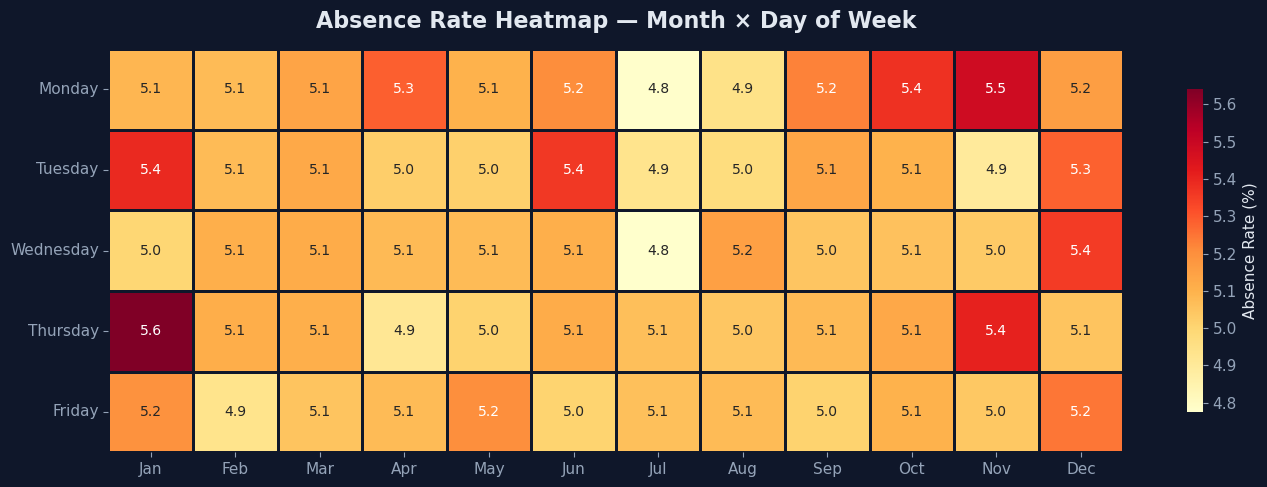

In [6]:
# Month × Day of Week heatmap
absence_heatmap = df_events.pivot_table(
    values='Absent', index='DayOfWeek', columns='Month', aggfunc='mean'
) * 100

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
absence_heatmap = absence_heatmap.reindex(day_order)
absence_heatmap.columns = [month_names[m] for m in absence_heatmap.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    absence_heatmap, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=1, linecolor=COLORS['bg'], ax=ax,
    cbar_kws={'label': 'Absence Rate (%)', 'shrink': 0.8},
    annot_kws={'size': 10}
)
ax.set_title('Absence Rate Heatmap — Month × Day of Week', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/absence_heatmap.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 4. Behavioral Patterns × Attrition

The critical question: **do employees who leave show different attendance patterns?**

In [7]:
# Merge attrition status to events for temporal analysis
attrition_map = df[['EmployeeID', 'Attrition', 'AttritionFlag']].copy()
df_events_attr = df_events.merge(attrition_map, on='EmployeeID', how='left')

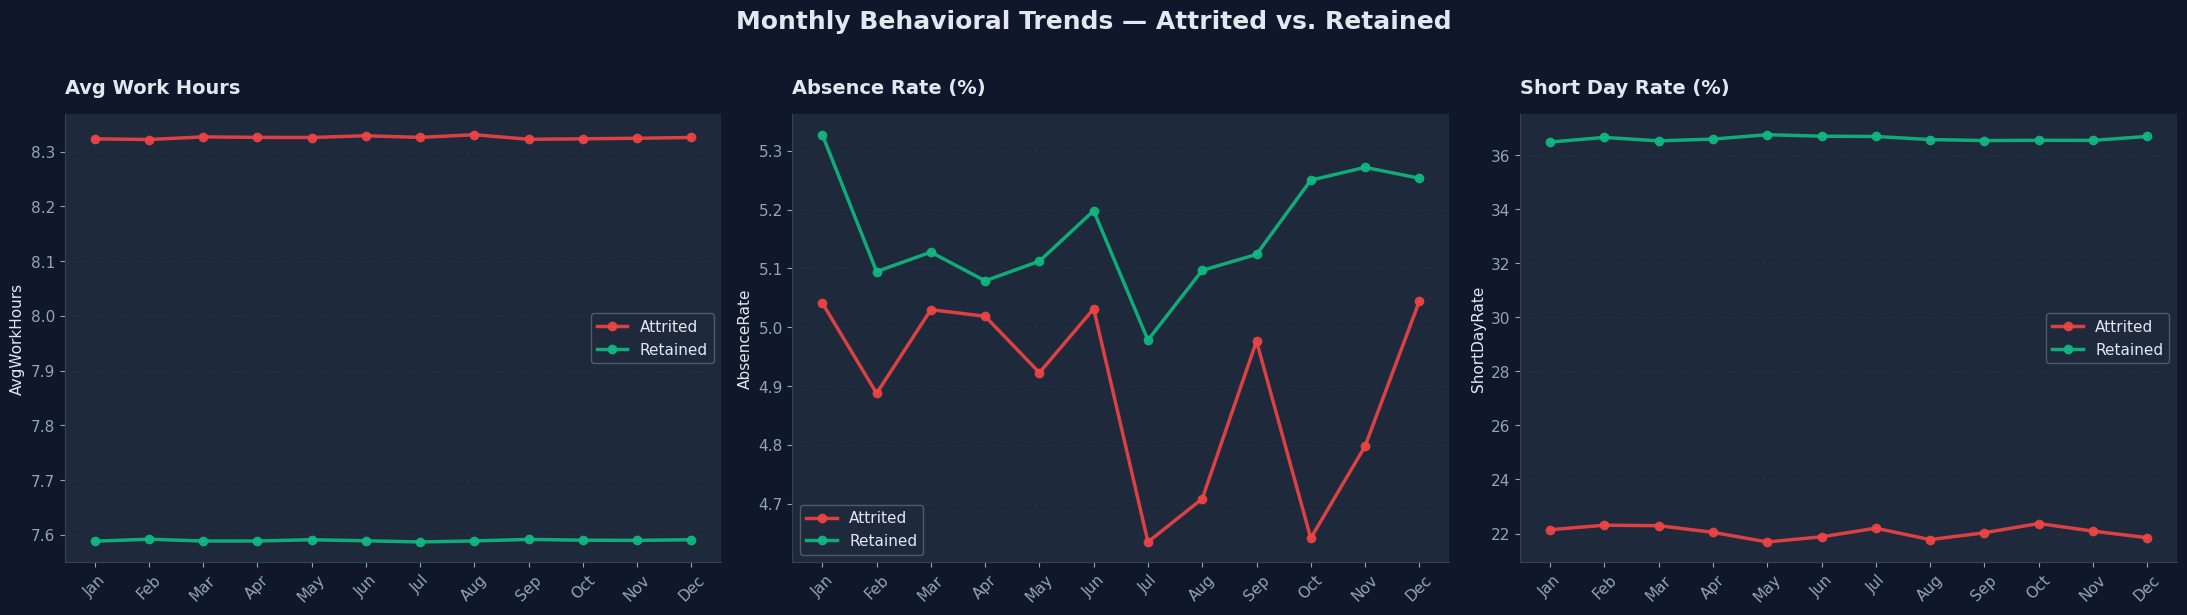

In [8]:
# Monthly engagement evolution by attrition status
monthly_by_status = df_events_attr.groupby(['Month', 'Attrition']).agg(
    AvgWorkHours=('WorkHours', 'mean'),
    AbsenceRate=('Absent', 'mean'),
    ShortDayRate=('ShortDay', 'mean')
).reset_index()
monthly_by_status['AbsenceRate'] *= 100
monthly_by_status['ShortDayRate'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Monthly Behavioral Trends — Attrited vs. Retained', fontsize=18, fontweight='bold', y=1.02)

metrics = [
    ('AvgWorkHours', 'Avg Work Hours'),
    ('AbsenceRate', 'Absence Rate (%)'),
    ('ShortDayRate', 'Short Day Rate (%)')
]

for ax, (metric, title) in zip(axes, metrics):
    for status, color in ATTRITION_COLORS.items():
        data = monthly_by_status[monthly_by_status['Attrition'] == status]
        label = 'Attrited' if status == 'Yes' else 'Retained'
        ax.plot(data['Month'], data[metric], color=color, marker='o', 
                linewidth=2.5, markersize=6, label=label, alpha=0.9)
    
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([month_names[m] for m in range(1, 13)], rotation=45)
    format_ax(ax, title, '', metric.replace('_', ' '))
    ax.legend(framealpha=0.3)

plt.tight_layout()
plt.savefig('../reports/behavioral_trends_attrition.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

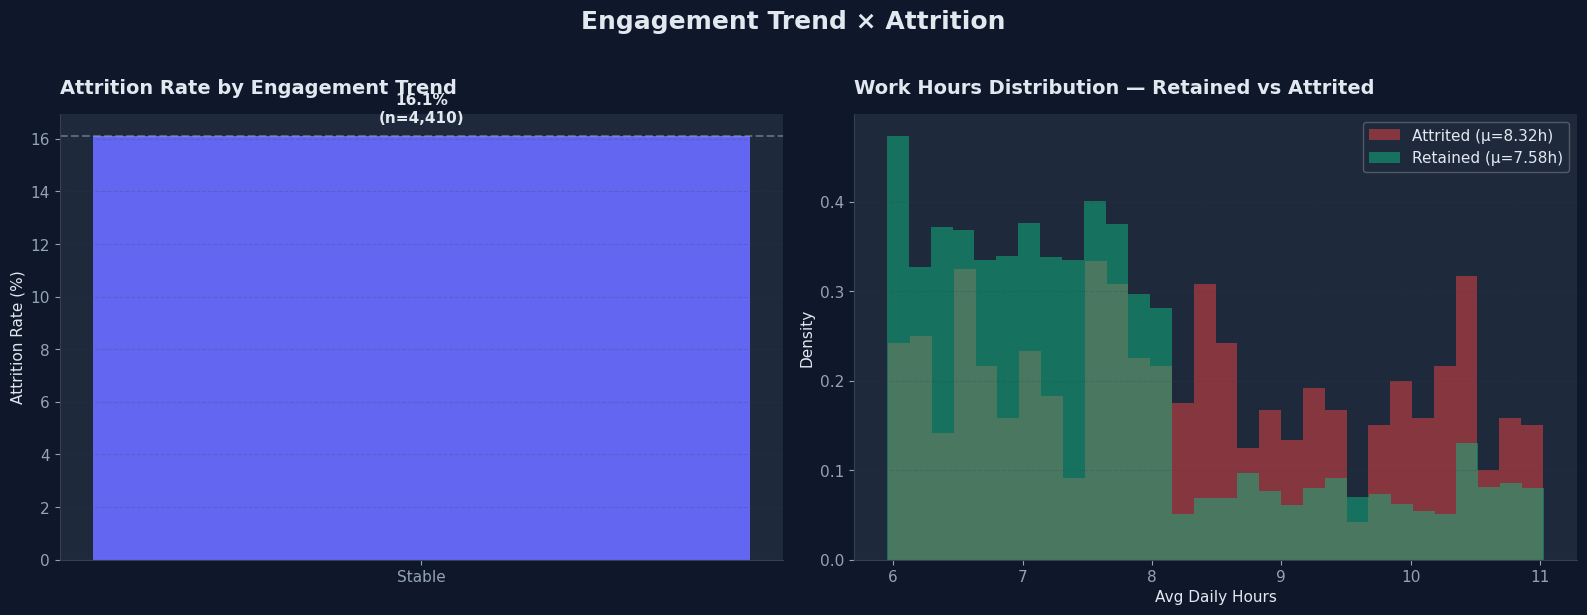

In [9]:
# Engagement trend category vs attrition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Engagement Trend × Attrition', fontsize=18, fontweight='bold', y=1.02)

# ── Trend distribution ──
ax = axes[0]
trend_attrition = df.groupby('TrendCategory')['AttritionFlag'].agg(['mean', 'count']).reset_index()
trend_attrition.columns = ['TrendCategory', 'Rate', 'Count']
trend_attrition['Rate'] *= 100
trend_attrition = trend_attrition.sort_values('Rate')

colors = [COLORS['success'] if t == 'Increasing' else COLORS['danger'] if t == 'Declining' 
          else COLORS['primary'] for t in trend_attrition['TrendCategory']]
bars = ax.bar(trend_attrition['TrendCategory'], trend_attrition['Rate'], color=colors, 
              edgecolor='none', width=0.5)
for bar, rate, count in zip(bars, trend_attrition['Rate'], trend_attrition['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 0.5, f'{rate:.1f}%\n(n={count:,})', 
            ha='center', fontsize=11, fontweight='bold', color=COLORS['text'])
ax.axhline(df['AttritionFlag'].mean() * 100, color=COLORS['muted'], linestyle='--', alpha=0.5)
format_ax(ax, 'Attrition Rate by Engagement Trend', '', 'Attrition Rate (%)')

# ── Work hours comparison: retained vs attrited ──
ax = axes[1]
for status, color in ATTRITION_COLORS.items():
    data = df[df['Attrition'] == status]['AvgDailyWorkHours'].dropna()
    label = 'Attrited' if status == 'Yes' else 'Retained'
    ax.hist(data, bins=30, alpha=0.5, color=color, label=f'{label} (μ={data.mean():.2f}h)', 
            density=True, edgecolor='none')
format_ax(ax, 'Work Hours Distribution — Retained vs Attrited', 'Avg Daily Hours', 'Density')
ax.legend(framealpha=0.3)

plt.tight_layout()
plt.savefig('../reports/engagement_attrition.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 5. Organizational Health — Burnout Risk

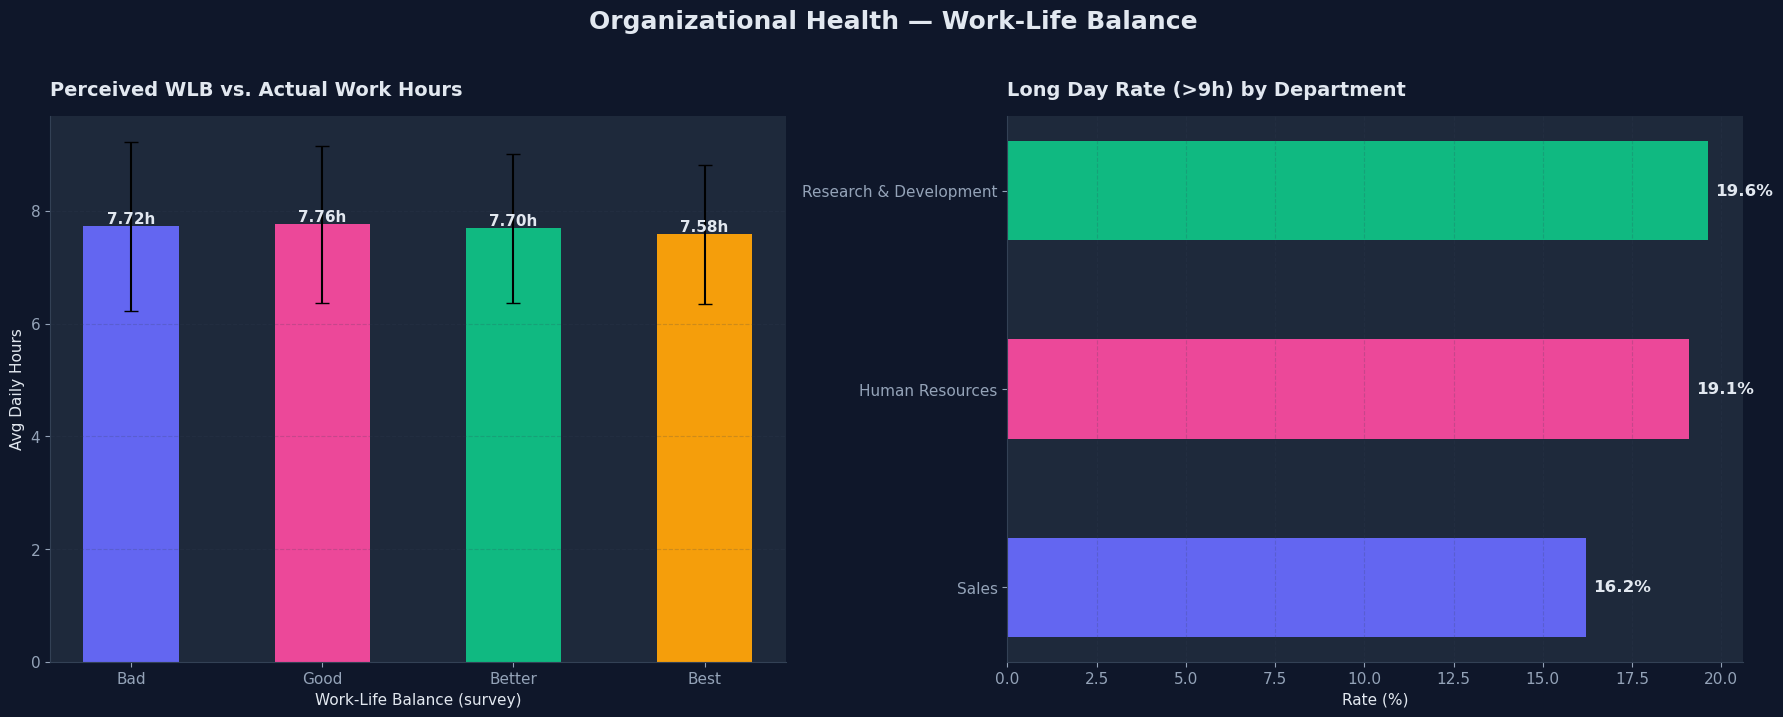

In [10]:
# Work-life balance: survey perception vs. actual behavior
wlb_labels = {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Organizational Health — Work-Life Balance', fontsize=18, fontweight='bold', y=1.02)

# ── Survey WLB vs actual hours ──
ax = axes[0]
wlb_hours = df.groupby('WorkLifeBalance')['AvgDailyWorkHours'].agg(['mean', 'std']).reset_index()
wlb_hours['Label'] = wlb_hours['WorkLifeBalance'].map(wlb_labels)
bars = ax.bar(wlb_hours['Label'], wlb_hours['mean'], 
              yerr=wlb_hours['std'], capsize=5,
              color=PALETTE_CAT[:4], edgecolor='none', width=0.5,
              error_kw={'color': COLORS['muted'], 'linewidth': 1.5})
for bar, mean in zip(bars, wlb_hours['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05, f'{mean:.2f}h', 
            ha='center', fontsize=11, fontweight='bold', color=COLORS['text'])
format_ax(ax, 'Perceived WLB vs. Actual Work Hours', 'Work-Life Balance (survey)', 'Avg Daily Hours')

# ── Long days by department ──
ax = axes[1]
dept_long = df.groupby('Department')['LongDayRate'].mean().sort_values()
bars = ax.barh(dept_long.index, dept_long.values, color=PALETTE_CAT[:3], edgecolor='none', height=0.5)
for bar, val in zip(bars, dept_long.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
            va='center', fontsize=12, fontweight='bold', color=COLORS['text'])
format_ax(ax, 'Long Day Rate (>9h) by Department', 'Rate (%)', '', grid_axis='x')

plt.tight_layout()
plt.savefig('../reports/org_health_wlb.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

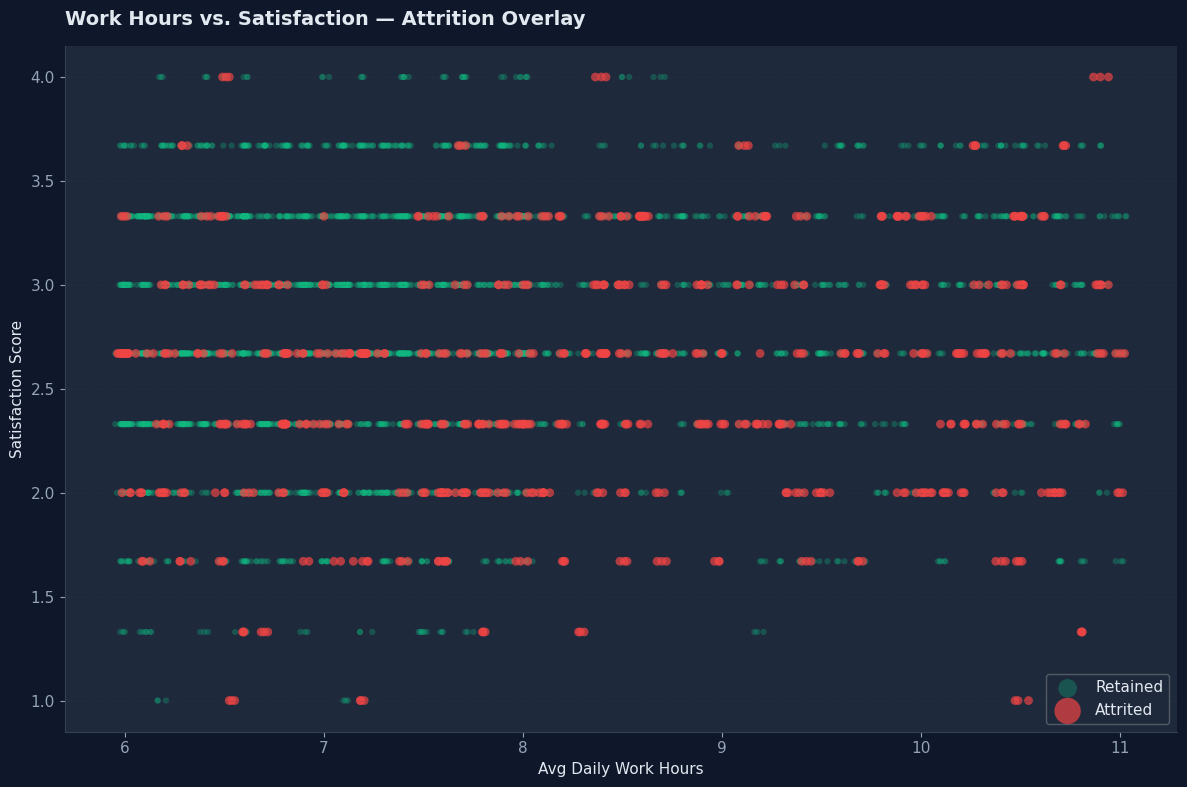

In [11]:
# Scatter: Work hours vs Satisfaction colored by Attrition
fig, ax = plt.subplots(figsize=(12, 8))

for status in ['No', 'Yes']:
    subset = df[df['Attrition'] == status]
    label = 'Retained' if status == 'No' else 'Attrited'
    ax.scatter(
        subset['AvgDailyWorkHours'], subset['SatisfactionScore'],
        c=ATTRITION_COLORS[status], alpha=0.3 if status == 'No' else 0.7,
        s=20 if status == 'No' else 40, label=label, edgecolors='none'
    )

format_ax(ax, 'Work Hours vs. Satisfaction — Attrition Overlay', 'Avg Daily Work Hours', 'Satisfaction Score')
ax.legend(framealpha=0.3, fontsize=11, markerscale=3)

plt.tight_layout()
plt.savefig('../reports/hours_satisfaction_scatter.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

---
## 6. Key Findings

### Attendance Patterns
- The standard work profile shows a consistent ~8h day with arrivals clustered around 9:30-10:00 AM
- Absence rates show seasonality, with potential peaks detectable across months
- Day-of-week patterns may reveal "bridge day" effects (Mondays/Fridays)

### Behavioral Signals of Attrition
- **Monthly trends** reveal whether employees who later left showed declining engagement patterns (fewer hours, more absences) in the months preceding their departure
- **Short day rate** is a potential early-warning metric — employees accumulating more short days may be mentally disengaging before formally resigning
- The **engagement trend** feature (calculated in notebook 00) provides a quantifiable measure of whether an employee's effort is increasing, stable, or declining

### Work-Life Balance
- Comparing perceived WLB (survey) with actual hours worked reveals whether self-assessments align with reality
- Departments with consistently high long-day rates face elevated burnout risk
- The scatter plot of hours × satisfaction reveals quadrants of concern (low satisfaction + high hours = immediate risk)